#**Movie Genres Classification**

##**Problem Statement** -
The objective of this project is to develop an NLP-based machine learning model that can automatically classify a movie into one of nine genres—such as Action, Comedy, Drama, Horror, Romance, Sci-Fi, and Thriller—based on approximately 1,000 characters of its movie script. The project involves cleaning and preprocessing the script text, extracting meaningful textual features using Bag of Words and n-grams, and training a Multinomial Naive Bayes classifier to predict the most likely movie genre.

In [70]:
#Importing all the necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score,recall_score,precision_score

# For generating random integer
from random import randint


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [38]:
df = pd.read_csv('/content/kaggle_movie_train.csv')

###**Exploring and understanding the dataset**

In [39]:
df.head()

,id,text,genre
0,0,"eady dead, maybe even wishing he was. INT. 2ND...",thriller
1,2,"t, summa cum laude and all. And I'm about to l...",comedy
2,3,"up Come, I have a surprise.... She takes him ...",drama
3,4,ded by the two detectives. INT. JEFF'S APARTME...,thriller
4,5,"nd dismounts, just as the other children reach...",drama


In [40]:
df.shape

(22579, 3)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22579 entries, 0 to 22578
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      22579 non-null  int64 
 1   text    22579 non-null  object
 2   genre   22579 non-null  object
dtypes: int64(1), object(2)
memory usage: 529.3+ KB


In [42]:
df.columns

Index(['id', 'text', 'genre'], dtype='object')

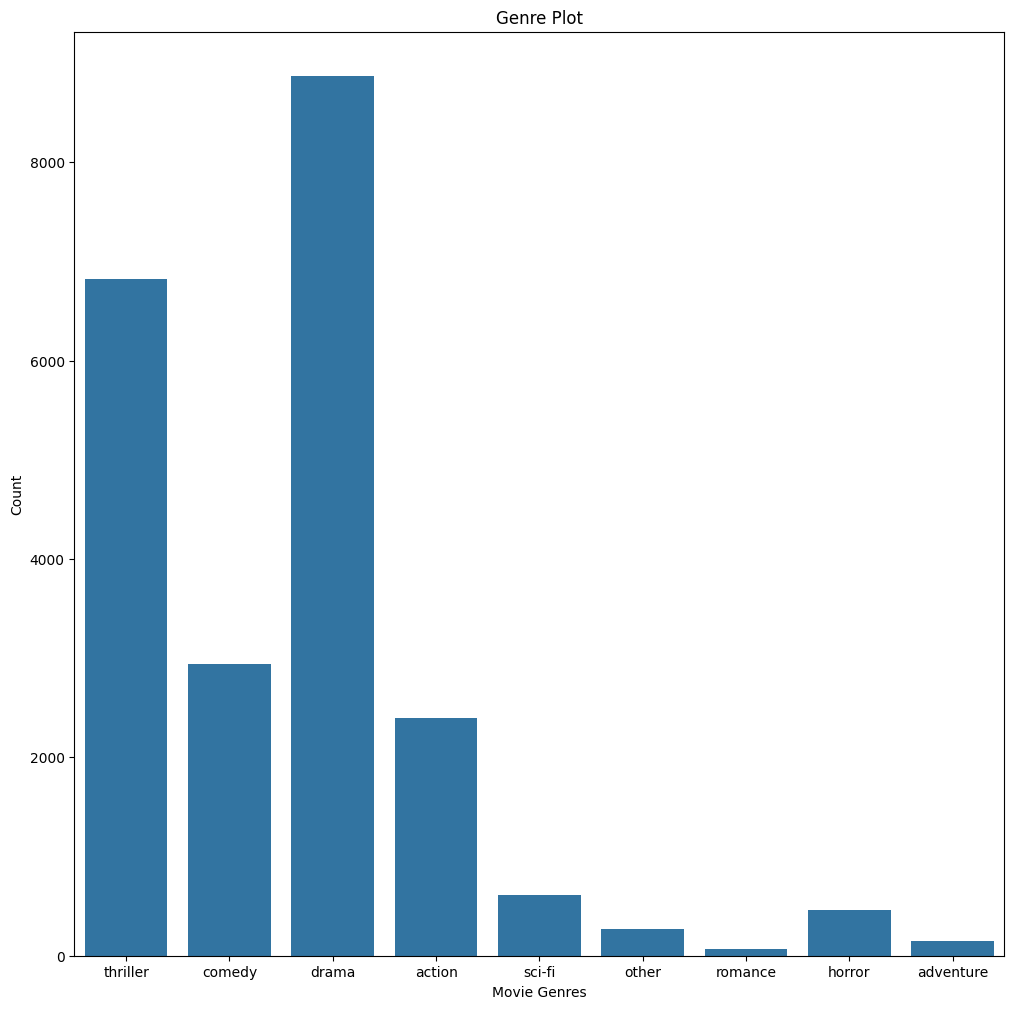

In [43]:
# Visualizing the count of 'genre' column from the dataset
plt.figure(figsize=(12,12))
sns.countplot(x='genre', data=df)
plt.xlabel('Movie Genres')
plt.ylabel('Count')
plt.title('Genre Plot')
plt.show()

##**Data Cleaning & Pre-processing**

In [44]:
# Finding unique genres
movie_genre = list(df['genre'].unique())
movie_genre.sort()
movie_genre

['action',
 'adventure',
 'comedy',
 'drama',
 'horror',
 'other',
 'romance',
 'sci-fi',
 'thriller']

In [45]:
# Mapping the genres to values
genre_mapper = {'other': 0, 'action': 1, 'adventure': 2, 'comedy':3, 'drama':4, 'horror':5, 'romance':6, 'sci-fi':7, 'thriller': 8}
df['genre'] = df['genre'].map(genre_mapper)
df.head(10)

,id,text,genre
0,0,"eady dead, maybe even wishing he was. INT. 2ND...",8
1,2,"t, summa cum laude and all. And I'm about to l...",3
2,3,"up Come, I have a surprise.... She takes him ...",4
3,4,ded by the two detectives. INT. JEFF'S APARTME...,8
4,5,"nd dismounts, just as the other children reach...",4
5,6,breadth of the bluff. Gabe pulls out his ancie...,8
6,7,uilding. A MAN in pajamas runs out into the ra...,8
7,9,ELLES AND RITA HAYWORTH Just disgustingly rich...,4
8,10,"Memphis goes back into the garage, Budgy cack...",8
9,11,e reels as the world spins. Sweat pours off hi...,1


In [46]:
# Finding any NaN values
df.isna().any()

,0
id,False
text,False
genre,False


In [47]:
# Removing the 'id' column
df.drop('id', axis=1, inplace=True)
df.columns

Index(['text', 'genre'], dtype='object')

In [48]:
# Cleaning the text
corpus = []
ps = PorterStemmer()

for i in range(0, df.shape[0]):

  # Cleaning special character from the dialog/script
  dialog = re.sub(pattern='[^a-zA-Z]', repl=' ', string=df['text'][i])

  # Converting the entire dialog/script into lower case
  dialog = dialog.lower()

  # Tokenizing the dialog/script by words
  words = dialog.split()

  # Removing the stop words
  dialog_words = [word for word in words if word not in set(stopwords.words('english'))]

  # Stemming the words
  words = [ps.stem(word) for word in dialog_words]

  # Joining the stemmed words
  dialog = ' '.join(words)

  # Creating a corpus
  corpus.append(dialog)


In [49]:
corpus[0:10]

['eadi dead mayb even wish int nd floor hallway three night orderli lead liza door orderli white guy open door step room three white guy mid look wild straight jacket jerri liza reach end rope shake head int decrepit hospit room night ball fetal realli head press cement tri sing jerri blue moon blue moon int nd floor hallway three night liza stand lean rail wall orderli sure go know bad orderli okay liza start hall orderli follow orderli got new patient last week want see liza wave hopeless stop chicken wire window end hall look light break jerri somewher orderli look gotta get back work',
 'summa cum laud launch brand new magazin call expos homag miss juli conroy xenia ohio juli grin juli know find excel editor chief ted yellow page juli let finger walk suddenli music chang peopl ted grin ted play song extend hand dare ask danc juli take hand better ted juli begin danc kiss b g charli jimmi feign tear charli sucker happi end hug jimmi hold start rise nelson hous cloud xenia ted v gues

In [50]:
df[df['genre']==4].index

Index([    2,     4,     7,    10,    11,    12,    13,    14,    15,    16,
       ...
       22553, 22560, 22561, 22563, 22564, 22567, 22568, 22571, 22574, 22575],
      dtype='int64', length=8873)

In [51]:
len(corpus)

22579

In [52]:
drama_words = []
for i in list(df[df['genre']==4].index):
  drama_words.append(corpus[i])

action_words = []
for i in list(df[df['genre']==1].index):
  action_words.append(corpus[i])

comedy_words = []
for i in list(df[df['genre']==3].index):
  comedy_words.append(corpus[i])

drama = ''
action = ''
comedy = ''
for i in range(0, 3):
  drama += drama_words[i]
  action += action_words[i]
  comedy += comedy_words[i]

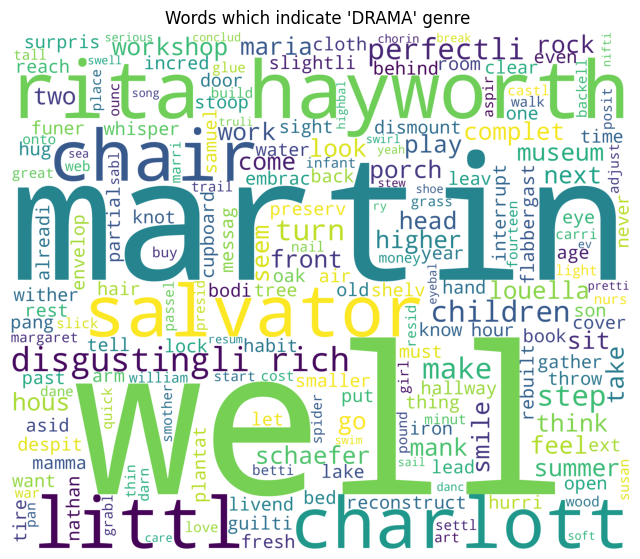

In [53]:
# Creating wordcloud for drama genre
from wordcloud import WordCloud
wordcloud1 = WordCloud(background_color='white', width=3000, height=2500).generate(drama)
plt.figure(figsize=(8,8))
plt.imshow(wordcloud1)
plt.axis('off')
plt.title("Words which indicate 'DRAMA' genre ")
plt.show()

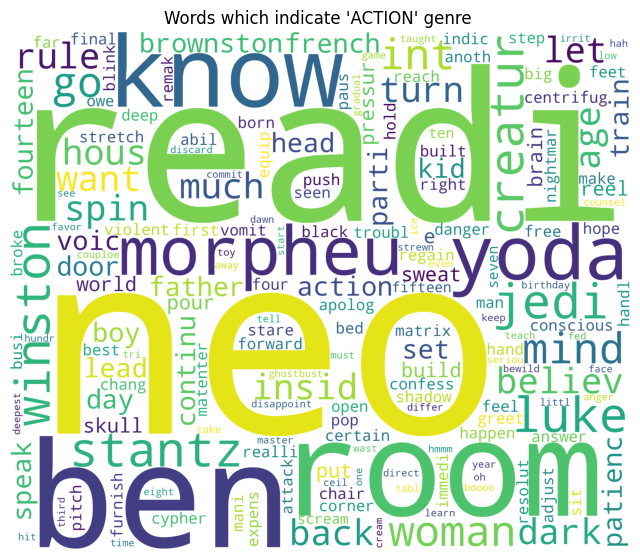

In [54]:
# Creating wordcloud for action genre
wordcloud2 = WordCloud(background_color='white', width=3000, height=2500).generate(action)
plt.figure(figsize=(8,8))
plt.imshow(wordcloud2)
plt.axis('off')
plt.title("Words which indicate 'ACTION' genre ")
plt.show()

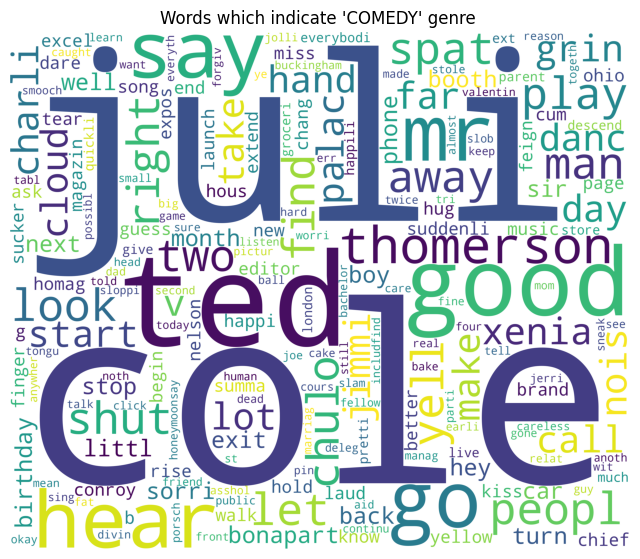

In [55]:
# Creating wordcloud for comedy genre
wordcloud3 = WordCloud(background_color='white', width=3000, height=2500).generate(comedy)
plt.figure(figsize=(8,8))
plt.imshow(wordcloud3)
plt.axis('off')
plt.title("Words which indicate 'COMEDY' genre ")
plt.show()

In [56]:
# Creating the Bag of Words model
cv = CountVectorizer(max_features=10000, ngram_range=(1,2))
X = cv.fit_transform(corpus).toarray()

In [57]:
y = df['genre'].values

##**Model Building**

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)
print('X_train size: {}, X_test size: {}'.format(X_train.shape, X_test.shape))

X_train size: (18063, 10000), X_test size: (4516, 10000)


In [61]:
# Fitting Naive Bayes to the Training set
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

MultinomialNB()

In [62]:
# Predicting the Test set results
nb_y_pred = nb_classifier.predict(X_test)

In [64]:
# Calculating Accuracy
score1 = accuracy_score(y_test, nb_y_pred)
print("---- Score ----")
print("Accuracy score is: {}%".format(round(score1*100,2)))

---- Score ----
Accuracy score is: 89.57%


In [65]:
# Making the Confusion Matrix
nb_cm = confusion_matrix(y_test, nb_y_pred)

In [66]:
nb_cm

array([[  62,    1,    0,    0,    1,    2,    0,    0,    0],
       [   0,  450,    0,    8,    6,    1,    0,    0,   11],
       [   0,    2,   41,    0,    1,    0,    0,    0,    1],
       [   0,    7,    0,  517,   18,    2,    0,    4,   11],
       [   3,   41,    1,   37, 1607,   21,    2,   11,  104],
       [   0,    1,    0,    1,    4,   73,    0,    0,    3],
       [   0,    1,    0,    0,    0,    0,   10,    0,    0],
       [   0,    2,    0,    1,    7,    1,    0,  114,    7],
       [   0,   14,    0,   21,   78,   12,    0,   22, 1171]])

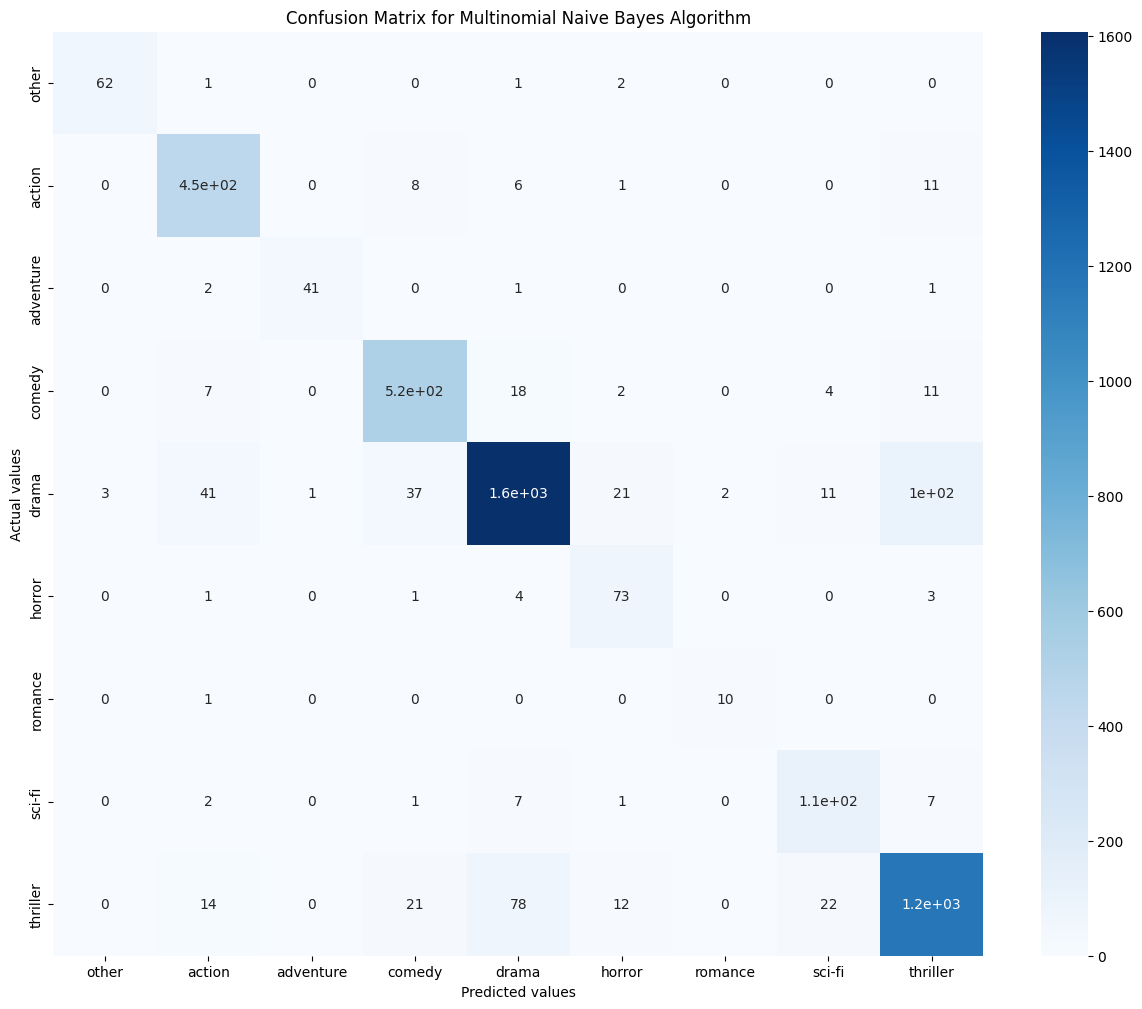

In [67]:
# Plotting the confusion matrix
plt.figure(figsize=(15,12))
axis_labels = ['other', 'action', 'adventure', 'comedy', 'drama', 'horror', 'romance', 'sci-fi', 'thriller']
sns.heatmap(data=nb_cm, annot=True, cmap="Blues", xticklabels=axis_labels, yticklabels=axis_labels)
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix for Multinomial Naive Bayes Algorithm')
plt.show()

In [68]:
classifier = MultinomialNB(alpha=0.1)
classifier.fit(X_train, y_train)

MultinomialNB(alpha=0.1)

##**Predictions**

In [69]:
def genre_prediction(sample_script):
  sample_script = re.sub(pattern='[^a-zA-Z]',repl=' ', string=sample_script)
  sample_script = sample_script.lower()
  sample_script_words = sample_script.split()
  sample_script_words = [word for word in sample_script_words if not word in set(stopwords.words('english'))]
  ps = PorterStemmer()
  final_script = [ps.stem(word) for word in sample_script_words]
  final_script = ' '.join(final_script)

  temp = cv.transform([final_script]).toarray()
  return classifier.predict(temp)[0]

In [71]:
# Loading test dataset
test = pd.read_csv('/content/kaggle_movie_test.csv')
test.columns

Index(['id', 'text'], dtype='object')

In [72]:
test.shape

(5589, 2)

In [73]:
test.drop('id', axis=1, inplace=True)
test.head(10)

,text
0,glances at her. BOOK Maybe I ought to learn t...
1,hout breaking stride. Tatiana sees her and can...
2,dead bodies. GEORDI Mitchell... DePaul... LANG...
3,take myself. BRANDON How bad is the other thi...
4,"her body to shield his own. KAY Freeze it, Bug..."
5,im from ear to ear. Ya want me to make a state...
6,"BEN We need to help Reed Sue shakes her head,..."
7,slowly. At the entrance to the alley stands a ...
8,edge of the field. Neil steps closer. THE TOMB...
9,"special, take ya in the kitchen and suck your ..."


In [74]:
# Prediction - 1
row = randint(0,test.shape[0]-1)
sample_script = test.text[row]

print('Script: {}'.format(sample_script))
value = genre_prediction(sample_script)
print('Prediction: {}'.format(list(genre_mapper.keys())[value]))

Script:  NIGHT Nathan and Gabrielle are having sex. They are focused and intent, although Gabrielle keeps chatting. GABRIELLE You were wonderful today, darling. Such authority with the ape man boy. It made me so hot for you. NATHAN Unnhh. GABRIELLE The way you are taming him, it sends chills down my girlish spine and... everywhere else, too. NATHAN Urgh. GABRIELLE Take me, darling! Tame your little monkey of love! There is a mutual climax. A moment of silence, then a spent Nathan rolls off onto his side of the bed. We see that it is really Lila in bed with him, not Gabrielle. LILA sighing Well, I'm tamed, Dr. Bronfman. Nathan stares up at the ceiling. NATHAN I'm glad... my assistant. CUT TO INT. LAB DAY We see a montage of interactions between Nathan, Puff, and Lila. 1 Nathan demonstrates the proper way to taste wine sniffing the cork, swishing the wine around in the glass, sipping, nodding in the affirmative to the waiter. Puff, inside his case, imitates it perfectly. 2 Nathan shows P

In [75]:
# Prediction - 2
row = randint(0,test.shape[0]-1)
sample_script = test.text[row]

print('Script: {}'.format(sample_script))
value = genre_prediction(sample_script)
print('Prediction: {}'.format(list(genre_mapper.keys())[value]))

Script: cking arm. Jack waits for Twombley as they enter a meadow. Jack aims his rifle at Twombley as he approaches. TWOMBLEY Hey, Hewitt! Slow the fuck down! Jack aims away, following an imaginary bird. Twombley steps alongside. JACK Safety on? TWOMBLEY Yeah. JACK This way. TWOMBLEY walking loudly Sun's gettin high. JACK fingers to lips Deers have ears too. CUT TO EXT. LARIVIERE CO. DAY Milky sky flatters LaRiviere Co., a sprawl of well digging, septic and snow plow equipment. Billboard declaimes LARIVIERE CO. OUR BUSINESS IS GOING IN THE HOLE! a motto repeated on every truck and piece of equipment. Wade's green Fairlane is parked outside the office. CUT TO INT. LARIVIERE CO. DAY Wade, puffing a cigarette, passes ELAINE'S LaRiviere secretary desk, her large red No Smoking sign, eases into an office modum chair. He unzips his jacket, slaps his cap against his thigh, spraying drops of melted snow. Gordon LaRiviere, speaking on the phone past a glass partition, calls to Wade LARIVIERE To

In [76]:
# Prediction - 3
row = randint(0,test.shape[0]-1)
sample_script = test.text[row]

print('Script: {}'.format(sample_script))
value = genre_prediction(sample_script)
print('Prediction: {}'.format(list(genre_mapper.keys())[value]))

Script: hat's right. Who are you? FRANK a dazzling smile I'm brother Frank. JULIA smiles Oh. FRANK I came for the wedding. He looks at her, eyes glittering. His hold on her is almost mesmeric. FRANK There is going to BE a wedding? JULIA Oh. Oh yes. FRANK Well can I come in or not? JULIA I'm sorry. Of course. You're very welcome. He steps inside. Now he is close to her, rain running down his face. We can hear his breath sense the almost intimidating intimacy of his presence. FRANK That's nice to know. pause Have you got a towel? INT. LOWER LANDING DAY JULIA stares down at the photograph. Off scrren, KIRSTY's voice KIRSTY O.S. Have you got a towel? JULIA looks up. At the top of the stairs, KIRSTY soaked from the tap. JULIA looks up, and hurriedly pockets the photograph. JULIA Kirsty. KIRSTY Hi. I got soaked. JULIA There's a towel in the bathroom. KIRSTY Which is where? JULIA Just to your left. KIRSTY ducks into the bathroom. We CUT BACK TO JULIA. It's clear the memory of her first meetin

In [77]:
# Prediction - 4
row = randint(0,test.shape[0]-1)
sample_script = test.text[row]

print('Script: {}'.format(sample_script))
value = genre_prediction(sample_script)
print('Prediction: {}'.format(list(genre_mapper.keys())[value]))

Script: nd confidential. Thanks. INT. PLANE NIGHT Fletch is sitting in a semi deserted flight on his way back home. He is hunched over an airline meal, eating with his right hand and turning in his mini recorder with his left. FLETCH Question But as he pushed the button down, the tape pops out. He fumbles it back in, and then pushes another button. FLETCH Question... TAPE RECORDER Fletch's voice playing back Day three on the beach. Fat Sam still hasn't moved, and FLETCH stopping the machine What's wrong with my life? He starts it right this time. FLETCH Question Why does a man marry a millionaire's daughter in Beverly Hills if he is already married to a girl who lives in a crappy one bedroom apartment in Utah? Answer Three million dollars. Big Question What's with Stanwyk and Cummings? I don't know. Bigger Question Why does Stanwyk want me to kill him? He takes a spoonful of airline food, chewing meditatively. FLETCH Biggest Question Why do I eat this sh t? to passing stewardess Miss, 

In [80]:
# Prediction - 5
row = randint(0,test.shape[0]-1)
sample_script = test.text[row]

print('Script: {}'.format(sample_script))
value = genre_prediction(sample_script)
print('Prediction: {}'.format(list(genre_mapper.keys())[value]))

Script: here weren't any robins. you know, birds. robins stood for love. and all of a sudden thousands of robins flew down and brought this blinding light of love. and it felt like that love would be the only thing that would make any difference. I guess. until the robins come there is trouble. JEFFREY Yeah I guess so. he turns to her You're a neat girl. SANDY So are you. laughs I mean you're a neat guy. We better get back. JEFFREY I guess so. you want to help me watch Frank?. I'm going to stake out Frank's place tomorrow. with a camera. Sandy starts the car and pulls out into the street. They begin driving back. 129. INT. WILLIAMS CAR NEIGHBORHOOD STREET NIGHT SANDY No, silly I'm still in school you know. but I'll meet you after school and you can tell me what you've learned. You better be careful, Jeffrey. JEFFREY I will. I'll pick you up on the same corner at three thirty five, okay? They pull up in front of Jeffrey's house. SANDY Okay. be careful. JEFFREY Okay, Sandy. 130. EXT. BEA